<h1 style="color: darkseagreen;text-align: center;"># TPs prog S8 </h1>

<h1 style="color: darkseagreen;text-align: center;">## TP1: Algorithmes de Tri</h1> 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
import random
import time

In [2]:
def generer_liste(nb):
  return [random.randint(x,x*10) for x in range(nb)]

In [3]:
Liste = generer_liste(5)
Liste

[0, 5, 11, 21, 10]

Le tri par sélection consiste à chercher le plus petit élément de la liste et à le placer en première
position. Une fois le plus petit élément positionné en première position, on recommence la
même opération en commençant à la deuxième position de la liste : on cherche le plus petit
élément compris dans la liste entre la 2e position et la fin de la liste, puis on place cet élément
à la deuxième position. On recommence ainsi en partant de la 3e position, puis de la 4e et ainsi
de suite jusqu’au bout de la liste.

In [4]:
def bubble_sort(Liste):
  l = Liste
  for i in range(len(l)):
    for j in range(i,len(l)):
      if l[j]<l[i]:
        l[i],l[j] = l[j] , l[i]

  return l

def select_sort(Liste):
  l = Liste

  min = 0
  argmin = 0

  for i in range(len(l)):
    min = l[i]
    argmin = i
    for j in range(i,len(l)):
      if l[j]<min:
        min= l[j]
        argmin = j
      l[i] , l[argmin]  = l[argmin], l[i]

  return l





In [5]:
print(bubble_sort(Liste))



[0, 5, 10, 11, 21]


In [6]:
print(select_sort(Liste))

[0, 5, 10, 11, 21]


Le tri par insertion consiste à classer les deux premiers éléments de la liste. Une fois que les
deux premiers sont ordonnés, on prend l’élément qui suit et on le classe à son tour dans ce qui
a déjà été classé. Pour chaque élément i de la liste, on sait que les éléments positionnés aux
indices de 0 à i-1 sont déjà classés. On va chercher la position j parmi les i-1 premiers éléments
de manière à ce que L[i] < L[j]. On insère alors T[i] à la position j.
Ecrire la fonction trier_par_insertion qui prend en paramètre une liste et retourne cette même
liste triée par ordre croissant.

In [7]:
def insert_sort(L, start=0, end=None):
    if end is None: 
        end = len(L)
    for i in range(start + 1, end):
        k = L[i]
        j = i
        while j > start and L[j - 1] > k:
            L[j] = L[j - 1]
            j -= 1
        L[j] = k
    return L    

In [8]:
l = generer_liste(5)

print(insert_sort(l))

[0, 4, 6, 16, 34]


Le tri par fusion est un algorithme qui propose de :

• Découper la liste en 2 parties de longueur égale (à un élément près) ;

• Trier les deux sous listes ;

• Fusionner ces deux sous listes triées pour n’en former qu’une seule qui soit elle-même
triée.

Avant de réaliser la fonction de tri en elle-même, écrire une fonction fusionner_listes qui prend
en paramètres 2 listes triées et retourne une liste triée issue de la fusion des deux listes passées
en paramètres.
Ecrire la fonction trier_par_fusion qui prend en paramètre une liste et retourne cette même
liste triée par ordre croissant.

In [ ]:
def quick_sort(l):
  if len(l)<=1:
    return l

  centre = len(l)//2
  pivot = l[centre]

  gauche = []
  middle = []
  droite = []

  for el in l:
    if el > pivot:
      droite.append(el)
    elif el == pivot:
      middle.append(el)
    else:
      gauche.append(el)
  return quick_sort(gauche) + middle + quick_sort(droite)

In [10]:
n = 5
n >> 1


2

In [ ]:
def minrun_length(n):
    r = 0
    while n >= 64:
        r |= n & 1
        n >>= 1
    return n + r


def insert_sort_2(L, start=0, end=None):
    if end is None:
        end = len(L)

    for i in range(start + 1, end):
        k = L[i]
        j = i
        while j > start and L[j - 1] > k:
            L[j] = L[j - 1]
            j -= 1
        L[j] = k


def detect_run(a, start, end):
    """
    Détecte un run naturel à partir de start.
    Si le run est décroissant, on l'inverse pour le rendre croissant.
    Retourne la longueur du run.
    """
    i = start + 1
    if i >= end:
        return 1

    # Run décroissant
    if a[i] < a[start]:
        while i < end and a[i] < a[i - 1]:
            i += 1
        a[start:i] = reversed(a[start:i])
    else:
        # Run croissant
        while i < end and a[i] >= a[i - 1]:
            i += 1

    return i - start


def make_runs(a):
    """
    Découpe a en runs (segments triés).
    Force une taille minimale minRun via insertion sort si besoin.
    Renvoie la liste de tuples (lo, hi) (hi exclu).
    """
    n = len(a)
    if n <= 1:
        return [(0, n)]

    minRun = minrun_length(n)
    runs = []
    i = 0

    while i < n:
        run_len = detect_run(a, i, n)

        if run_len < minRun:
            force = min(minRun, n - i)
            insert_sort_2(a, i, i + force)
            run_len = force

        runs.append((i, i + run_len))
        i += run_len

    return runs


def fusion_2(l1, l2):
    """
    Fusionne 2 listes triées (l1, l2) et renvoie une nouvelle liste triée.
    """
    i = j = 0
    res = []

    while i < len(l1) and j < len(l2):
        if l1[i] <= l2[j]:
            res.append(l1[i])
            i += 1
        else:
            res.append(l2[j])
            j += 1

    res.extend(l1[i:])
    res.extend(l2[j:])
    return res


def merge_runs(a, lo, mid, hi):
    """
    Fusionne a[lo:mid] et a[mid:hi] (déjà triés) dans a[lo:hi].
    """
    a[lo:hi] = fusion_2(a[lo:mid], a[mid:hi])


def merge_all_runs(a, runs):
    """
    Fusionne tous les runs jusqu'à n'en garder qu'un.
    """
    while len(runs) > 1:
        new_runs = []
        i = 0

        while i < len(runs):
            if i + 1 == len(runs):
                new_runs.append(runs[i])
                break

            lo1, hi1 = runs[i]
            lo2, hi2 = runs[i + 1]

            merge_runs(a, lo1, hi1, hi2)
            new_runs.append((lo1, hi2))
            i += 2

        runs = new_runs

    return a


def timsort(a):
    runs = make_runs(a)
    return merge_all_runs(a, runs)

58


Merge sort 

In [ ]:
def fusion_2(l1, l2):
    """
    Fusionne 2 listes triées (l1, l2) et renvoie une nouvelle liste triée.
    """
    i = j = 0
    res = []

    while i < len(l1) and j < len(l2):
        if l1[i] <= l2[j]:
            res.append(l1[i])
            i += 1
        else:
            res.append(l2[j])
            j += 1

    res.extend(l1[i:])
    res.extend(l2[j:])
    return res

def merge_sort(l):
  if len(l)<=1:
    return l

  middle = len(l) // 2

  left = merge_sort(l[:middle])
  right = merge_sort(l[middle:])

  return fusion_2(left,right)

In [13]:
def benchmark(func, data):
    arr = data.copy() 
    
    start = time.perf_counter()  # plus précis que time.time()
    func(arr)
    end = time.perf_counter()
    
    return end - start  

def benchmark_iter_rec(func, n):
    start = time.perf_counter()
    try:    
        func(n)
    except RecursionError:
        return 0
    end = time.perf_counter()
    return end - start

bubble_sort: 0.009085488971322775 seconds
select_sort: 0.01266459608450532 seconds
insert_sort: 0.0034578770864754915 seconds
quick_sort: 0.0004197268281131983 seconds
merge_sort: 0.0006880389992147684 seconds
timsort: 0.000691116089001298 seconds


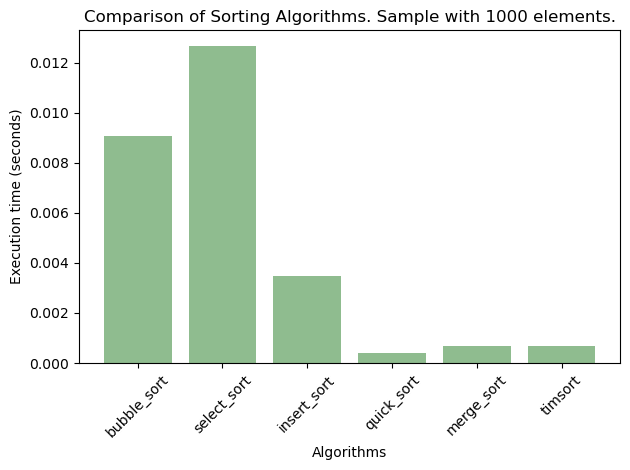

In [14]:
ltest = generer_liste(1000)


sort_functions = [bubble_sort, select_sort, insert_sort, quick_sort, merge_sort, timsort]

times = {}
for elem in sort_functions:
    times[elem.__name__] = benchmark(elem, ltest)

for k, v in times.items(): 
    print(f"{k}: {v} seconds")
df = pd.DataFrame(data=times , index=[0])
    

plt.figure()
plt.bar(times.keys(), times.values(), color='darkseagreen')
plt.xticks(rotation=45)
plt.xlabel("Algorithms")
plt.ylabel("Execution time (seconds)")
plt.title("Comparison of Sorting Algorithms. Sample with 1000 elements.")
plt.tight_layout()
plt.show()



Recursion How does it work?

In [15]:
# Iterative
def walk_i(n):
    for step in range(1,n+1):
        print(f'Took step #{step}')

# Recursive
def walk(n):
    if n <= 0:
        return 'Done'
    walk(n - 1)
    print(n)

print(walk_i(100))

Took step #1
Took step #2
Took step #3
Took step #4
Took step #5
Took step #6
Took step #7
Took step #8
Took step #9
Took step #10
Took step #11
Took step #12
Took step #13
Took step #14
Took step #15
Took step #16
Took step #17
Took step #18
Took step #19
Took step #20
Took step #21
Took step #22
Took step #23
Took step #24
Took step #25
Took step #26
Took step #27
Took step #28
Took step #29
Took step #30
Took step #31
Took step #32
Took step #33
Took step #34
Took step #35
Took step #36
Took step #37
Took step #38
Took step #39
Took step #40
Took step #41
Took step #42
Took step #43
Took step #44
Took step #45
Took step #46
Took step #47
Took step #48
Took step #49
Took step #50
Took step #51
Took step #52
Took step #53
Took step #54
Took step #55
Took step #56
Took step #57
Took step #58
Took step #59
Took step #60
Took step #61
Took step #62
Took step #63
Took step #64
Took step #65
Took step #66
Took step #67
Took step #68
Took step #69
Took step #70
Took step #71
Took step #72
T

In [16]:
# Recursive
def factorial(n):
    if n == 0:
        return 1
    return n * factorial(n - 1)

# Iterative
def factorial_i(n):
    res = 1
    for i in range(1,n+1):
        res *= i
    return res

def fib(n):
    if n <= 1:
        return n
    return fib(n - 1) + fib(n - 2)


dico = {}

def perfs_factorial(dico):
    for i in [10, 100, 1000, 10000]:
        dico[f'factorial_rec_{i}'] = f"Iterative factorial{i} took {benchmark_iter_rec(factorial, i)} seconds"
        dico[f'factorial_iter_{i}'] = f"Iterative factorial{i} took {benchmark_iter_rec(factorial_i, i)} seconds"
    return dico

perfs_factorial(dico)
for k, v in dico.items():
    print(f"{v}")



Iterative factorial10 took 1.7730053514242172e-06 seconds
Iterative factorial10 took 1.5941914170980453e-06 seconds
Iterative factorial100 took 5.152076482772827e-06 seconds
Iterative factorial100 took 3.81888821721077e-06 seconds
Iterative factorial1000 took 0.00018670805729925632 seconds
Iterative factorial1000 took 9.725918062031269e-05 seconds
Iterative factorial10000 took 0 seconds
Iterative factorial10000 took 0.010891740908846259 seconds


In [17]:
print(factorial(5))

120


What python does is use a Stack LIFO (Last In First Out) to keep track of the function calls. When a function is called, it is added to the top of the stack. When a function returns, it is removed from the top of the stack. 
Then python executes the function calls in the order they were added to the stack. When a function calls itself, it adds another instance of that function to the stack. This process continues until a base case is reached, at which point the function starts returning and unwinding the stack.



There is a limit in recursion. If the recursion is too deep, it will raise a RecursionError. This is because the stack has a limited size, and if the recursion goes too deep, it will exceed the maximum stack size.



<h3 style="color: darkseagreen;"Recursivity"</h3> 

Pour comprendre la Programmation Orientée Objet (POO), il faut oublier un instant le code et regarder le monde réel.

Voici une explication étape par étape, des concepts de base jusqu'à l'application en Python.

<h3 style="color: darkseagreen;"Le concept : Le "Moule" et l' "Objet"</h3> 

Imagine que tu travailles dans une usine de **voitures**.

La Classe, c'est le plan de fabrication (le dessin technique). Le plan ne roule pas, il explique comment une voiture doit être construite : elle doit avoir 4 roues, une couleur, et un moteur.

L'Objet (ou l'Instance), c'est la voiture réelle qui sort de l'usine. À partir du même plan, tu peux fabriquer une voiture rouge, une bleue ou une verte. Ce sont des objets différents, mais basés sur le même plan.

<h1 style="color: darkseagreen;">Les 2 pilliers d'une classe</h1>

Les attributs : ce sont les caractéristiques de la voiture (couleur, nombre de roues, type de moteur). Ils décrivent l'état de l'objet.

Les méthodes : ce sont les actions que la voiture peut faire (démarrer, freiner, tourner). Elles définissent le comportement de l'objet.
<h1 style="color: darkseagreen;">Comment créer une classe en Python ?</h1>


In [18]:
class Car: # Toujours en majuscule
    # constructeur defini ce qu'aura Voiture à chaque construction
    def __init__(self,brand,model,color,motor): # init est le constructeur de la class
        self.brand = brand
        self.model = model
        self.color = color
        self.motor = motor
        self.speed = 0

    def show_info(self):
        print(f"This car is a {self.color} {self.brand} {self.model} with a {self.motor} motor")
    
    def accelerate(self,value):
        self.speed += value
        print(f"Car's speed is {self.speed}")

In [19]:
my_car = Car("Peugeot","205","White",'1.5L')
your_car = Car("Renault","megane","grey",'2.9L')


car_t = Car("Tesla","Model 3","Red",'2.9L')
my_car.show_info()
your_car.show_info()
car_t.show_info()

This car is a White Peugeot 205 with a 1.5L motor
This car is a grey Renault megane with a 2.9L motor
This car is a Red Tesla Model 3 with a 2.9L motor


<h3 style="color: indianred;">On peut appliquer ça a des graphes</h3>

In [20]:
class Node:
    def __init__(self,nom):
        self.nom = nom
        self.neighboors = [] # array with neighboors nodes

        self.visite = False  # for graph traversal algorithms
        self.parent = None    
        self.distance = float('inf') # for shortest path algorithms (Dijkstra, Bellman-Ford)
    
    def add_neighboor(self, new_neighboor):
        if new_neighboor not in set(self.neighboors):
            self.neighboors.append(new_neighboor)

class Graphe:

    def __init__(self):
        self.nodes = {}
    
    def add_node(self,name):
        if name not in self.nodes:
            self.nodes[name] = Node(name)

    def add_edge(self, u, v, oriented=False):
        """
        Connect u et v. 
        if oriented=True  : add edge (u -> v)
        if oriented=False : add edge (u <-> v)
        """

        # make sure edges exists 

        if not self.nodes[u] or self.nodes[v]:

            self.add_node(u)
            self.add_node(v)
        
        Node_u = self.nodes[u]
        Node_v = self.nodes[v]

        if Node_v not in set(Node_u.neighboors):
            Node_u.add_neighboor(Node_v)
        
        if not oriented:
            if Node_u not in set(Node_v.neighboors):
                Node_v.add_neighboor(Node_u)

In [21]:


def trans(x):
    if x == 0: return [0]
    bit = []
    while x:
        bit.append(x % 2)
        x >>= 1
    return bit[::-1]

trans(51)

[1, 1, 0, 0, 1, 1]

In [22]:
def tobin(x):
        return tobin(x/2) + [x%2] if x > 1 else [x]

tobin(51)

[0.796875, 1.59375, 1.1875, 0.375, 0.75, 1.5, 1]